**T1 - Tic Tac Toe com ML**

**Classificador Random Forest (floresta aleatória)**

Classificação do estado do tabuleiro: Tem jogo, Jogador X venceu, Jogador O venceu e Empate.

Kamilah Santos e Amanda Wilmsen

Fluxo: ler os CSVs preparados → escolher os parâmetros na **validação** → avaliar uma única vez no **teste** → comparar as abordagens 1 e 2.
Executar de cima para baixo, com o notebook na raiz do repositório (ao lado da pasta `dataset`).

In [1]:
import time

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

**Configurações**

Abordagem 1: só as 9 casas do tabuleiro (b=0, x=1, o=-1). Abordagem 2: 15 características calculadas (qtd de X e O, posições ocupadas, linhas com 2 X/O, casas vazias e jogador da vez).

In [2]:
SEED = 42
BASE = "dataset/processado"   # pasta com os CSVs preparados

CLASSES = ["Tem jogo", "Jogador X venceu", "Jogador O venceu", "Empate"]
abordagens = {"abordagem_1": "A1 (tabuleiro)", "abordagem_2": "A2 (características)"}

**Carga dos dados**

Cada abordagem tem treino, validação e teste (já divididos fisicamente). As colunas `id_tabuleiro` (só identificador) e `estado` (a resposta) não entram como características.

In [3]:
dados = {}
for ab in abordagens:
    d = {}
    for conjunto, sufixo in [("treino", "train"), ("validacao", "val"), ("teste", "test")]:
        df = pd.read_csv(f"{BASE}/{ab}/{conjunto}.csv")
        d[f"ids_{sufixo}"] = df["id_tabuleiro"]
        d[f"y_{sufixo}"] = df["estado"].values
        d[f"X_{sufixo}"] = df.drop(columns=["id_tabuleiro", "estado"])
    dados[ab] = d

for ab in abordagens:
    print(abordagens[ab])
    print("  X_train:", dados[ab]["X_train"].shape, " y_train:", dados[ab]["y_train"].shape)
    print("  X_val:  ", dados[ab]["X_val"].shape, " y_val:  ", dados[ab]["y_val"].shape)
    print("  X_test: ", dados[ab]["X_test"].shape, " y_test: ", dados[ab]["y_test"].shape)

A1 (tabuleiro)
  X_train: (560, 9)  y_train: (560,)
  X_val:   (92, 9)  y_val:   (92,)
  X_test:  (93, 9)  y_test:  (93,)
A2 (características)
  X_train: (560, 15)  y_train: (560,)
  X_val:   (92, 15)  y_val:   (92,)
  X_test:  (93, 15)  y_test:  (93,)


In [4]:
# classes em cada conjunto
d = dados["abordagem_1"]
pd.DataFrame({"treino": pd.Series(d["y_train"]).value_counts(),
              "validacao": pd.Series(d["y_val"]).value_counts(),
              "teste": pd.Series(d["y_test"]).value_counts()})

,treino,validacao,teste
Empate,140,2,3
Jogador O venceu,140,30,30
Jogador X venceu,140,30,30
Tem jogo,140,30,30


In [5]:
# nenhum tabuleiro pode aparecer em mais de uma divisão (senão o teste seria "colado" do treino)
ids_train, ids_val, ids_test = set(d["ids_train"]), set(d["ids_val"]), set(d["ids_test"])
print("treino x validação:", len(ids_train & ids_val))
print("treino x teste:    ", len(ids_train & ids_test))
print("validação x teste: ", len(ids_val & ids_test))
print("linhas do treino:", len(d["ids_train"]), "- tabuleiros distintos:", len(ids_train),
      "(repetições = empates reamostrados no treino)")

treino x validação: 0
treino x teste:     0
validação x teste:  0
linhas do treino: 560 - tabuleiros distintos: 431 (repetições = empates reamostrados no treino)


**Métricas**

Acurácia, precision, recall e F-measure. Como a classe Empate tem pouquíssimos exemplos (3 no teste), usamos a média **macro** (cada classe pesa igual).

In [6]:
def metricas(y_real, y_pred):
    return {"acc": accuracy_score(y_real, y_pred),
            "precision": precision_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0),
            "recall": recall_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0),
            "f1_macro": f1_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0)}

**O algoritmo Random Forest e os parâmetros a testar**

A Random Forest é um conjunto (*ensemble*) de árvores de decisão. Cada árvore é treinada com uma amostra sorteada do treino (*bootstrap*) e, em cada divisão, só considera um subconjunto sorteado das características. Para classificar, todas as árvores votam e vence a classe mais votada. Como cada árvore erra de um jeito, os erros se compensam: a floresta costuma ter menos overfitting que uma árvore sozinha. Em troca, perde-se a interpretabilidade e a predição é mais lenta (é preciso consultar todas as árvores).

- `n_estimators`: nº de árvores da floresta. Mais árvores deixam o voto mais estável, mas aumentam o custo.
- `max_depth`: profundidade máxima de cada árvore (controla o overfitting de cada uma).
- `min_samples_leaf`: nº mínimo de exemplos por folha; valores maiores deixam as árvores mais simples.

Como na árvore, não é preciso normalizar as características, e o treino já vem balanceado (não usamos `class_weight`).

In [7]:
# valores testados (do mais simples ao mais complexo)
lista_n_arvores = [10, 50, 100, 200]            # default 100
lista_max_depth = [3, 5, 8, None]               # default None (sem limite)
lista_min_leaf = [5, 2, 1]                      # default 1

print("Combinações por abordagem:", len(lista_n_arvores) * len(lista_max_depth) * len(lista_min_leaf))

Combinações por abordagem: 48


In [8]:
def criar_modelo(ab, n_arvores, max_depth, min_leaf):
    return RandomForestClassifier(random_state=SEED,
                                  n_estimators=n_arvores,
                                  max_depth=max_depth,
                                  min_samples_leaf=min_leaf,
                                  class_weight=None)   # default None. 'balanced' para equilibrar classes

**Ajuste de parâmetros na validação**

Treina um modelo para cada combinação, nas duas abordagens. O melhor é o de maior F1 macro na **validação** (desempate por acurácia; se ainda empatar, fica o primeiro, que é o mais simples). O teste não é usado aqui.

Guardamos também o F1 de treino: se for bem maior que o de validação, é sinal de overfitting.

In [9]:
resultados = []   # uma linha para cada combinação testada
melhor = {}       # melhor modelo de cada abordagem (escolhido pela validação)

for ab in abordagens:
    d = dados[ab]
    for n_arvores in lista_n_arvores:
        for max_depth in lista_max_depth:
            for min_leaf in lista_min_leaf:
                modelo = criar_modelo(ab, n_arvores, max_depth, min_leaf)
                modelo.fit(d["X_train"], d["y_train"])
                m_train = metricas(d["y_train"], modelo.predict(d["X_train"]))
                m_val = metricas(d["y_val"], modelo.predict(d["X_val"]))

                resultados.append({"abordagem": abordagens[ab], "n_arvores": n_arvores, "max_depth": max_depth,
                                   "min_leaf": min_leaf, "f1_treino": m_train["f1_macro"],
                                   "val_acc": m_val["acc"], "val_f1_macro": m_val["f1_macro"]})

                chave = (m_val["f1_macro"], m_val["acc"])
                if ab not in melhor or chave > melhor[ab]["chave"]:
                    melhor[ab] = {"chave": chave, "f1_treino": m_train["f1_macro"], "modelo": modelo,
                                  "params": {"n_arvores": n_arvores, "max_depth": max_depth, "min_leaf": min_leaf}}

resultados = pd.DataFrame(resultados)
print("Combinações testadas:", len(resultados))

Combinações testadas: 96


In [10]:
# melhor configuração de cada abordagem
for ab in abordagens:
    print(abordagens[ab], "->", melhor[ab]["params"], " F1 validação =", round(melhor[ab]["chave"][0], 3))

A1 (tabuleiro) -> {'n_arvores': 200, 'max_depth': None, 'min_leaf': 2}  F1 validação = 0.767
A2 (características) -> {'n_arvores': 10, 'max_depth': None, 'min_leaf': 1}  F1 validação = 0.94


In [11]:
# as 5 melhores combinações de cada abordagem (validação)
for ab in abordagens:
    print(abordagens[ab])
    top = resultados[resultados.abordagem == abordagens[ab]].sort_values(["val_f1_macro", "val_acc"], ascending=False)
    display(top.head(5).round(3))

A1 (tabuleiro)


,abordagem,n_arvores,max_depth,min_leaf,f1_treino,val_acc,val_f1_macro
46,A1 (tabuleiro),200,NaN,2,0.993,0.761,0.767
34,A1 (tabuleiro),100,NaN,2,0.995,0.761,0.737
22,A1 (tabuleiro),50,NaN,2,0.991,0.761,0.736
32,A1 (tabuleiro),100,8.0,1,1.000,0.826,0.727
44,A1 (tabuleiro),200,8.0,1,1.000,0.793,0.723


A2 (características)


,abordagem,n_arvores,max_depth,min_leaf,f1_treino,val_acc,val_f1_macro
59,A2 (características),10,NaN,1,0.986,0.924,0.940
56,A2 (características),10,8.0,1,0.982,0.913,0.931
58,A2 (características),10,NaN,2,0.967,0.913,0.931
80,A2 (características),100,8.0,1,0.976,0.913,0.931
92,A2 (características),200,8.0,1,0.976,0.913,0.931


**Avaliação final no teste**

A configuração escolhida na validação é avaliada **uma única vez** no teste. Medimos também o custo: tempo médio (20 repetições) de treino e de predição.

In [12]:
tabela = []
previsoes = {}

for ab in abordagens:
    d = dados[ab]
    modelo = melhor[ab]["modelo"]
    params = melhor[ab]["params"]

    # custo: tempo de treino e de predição
    t0 = time.perf_counter()
    for _ in range(20):
        criar_modelo(ab, **params).fit(d["X_train"], d["y_train"])
    tempo_treino = (time.perf_counter() - t0) / 20 * 1000
    t0 = time.perf_counter()
    for _ in range(20):
        modelo.predict(d["X_test"])
    tempo_pred = (time.perf_counter() - t0) / 20 * 1000

    # teste (uma única vez)
    previsoes[ab] = modelo.predict(d["X_test"])
    m = metricas(d["y_test"], previsoes[ab])
    tabela.append({"abordagem": abordagens[ab],
                   "acuracia": m["acc"], "precision": m["precision"], "recall": m["recall"], "f1_macro": m["f1_macro"],
                   "gap_treino_val": melhor[ab]["f1_treino"] - melhor[ab]["chave"][0],
                   "tempo_treino_ms": tempo_treino, "tempo_pred_ms": tempo_pred})

tabela = pd.DataFrame(tabela)
tabela.round(3)

,abordagem,acuracia,precision,recall,f1_macro,gap_treino_val,tempo_treino_ms,tempo_pred_ms
0,A1 (tabuleiro),0.742,0.682,0.725,0.696,0.226,234.128,15.659
1,A2 (características),0.903,0.925,0.925,0.924,0.046,13.270,1.536


**Resultado por classe e matriz de confusão (teste)**

Mostra onde o modelo erra. Atenção: o teste tem poucos empates, então as métricas dessa classe são instáveis (um único erro muda muito o valor).

In [13]:
for ab in abordagens:
    print(abordagens[ab])
    print(classification_report(dados[ab]["y_test"], previsoes[ab], labels=CLASSES, zero_division=0))

A1 (tabuleiro)
                  precision    recall  f1-score   support

        Tem jogo       0.65      0.50      0.57        30
Jogador X venceu       0.79      0.77      0.78        30
Jogador O venceu       0.78      0.97      0.87        30
          Empate       0.50      0.67      0.57         3

        accuracy                           0.74        93
       macro avg       0.68      0.72      0.70        93
    weighted avg       0.74      0.74      0.73        93

A2 (características)
                  precision    recall  f1-score   support

        Tem jogo       0.89      0.80      0.84        30
Jogador X venceu       0.84      0.90      0.87        30
Jogador O venceu       0.97      1.00      0.98        30
          Empate       1.00      1.00      1.00         3

        accuracy                           0.90        93
       macro avg       0.93      0.93      0.92        93
    weighted avg       0.90      0.90      0.90        93



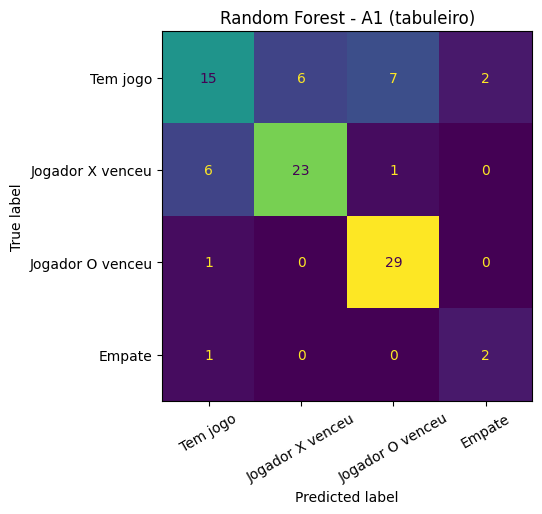

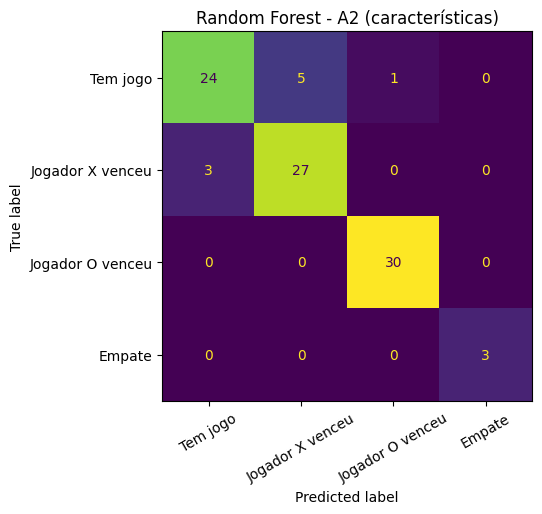

In [14]:
for ab in abordagens:
    resultado = confusion_matrix(dados[ab]["y_test"], previsoes[ab], labels=CLASSES)
    ConfusionMatrixDisplay(resultado, display_labels=CLASSES).plot(xticks_rotation=30, colorbar=False)
    plt.title(f"Random Forest - {abordagens[ab]}")
    plt.show()

**Efeito do número de árvores (treino × validação)**

Para cada `n_estimators`, a melhor configuração. A floresta tende a estabilizar a partir de certo número de árvores; depois disso, mais árvores só aumentam o custo.

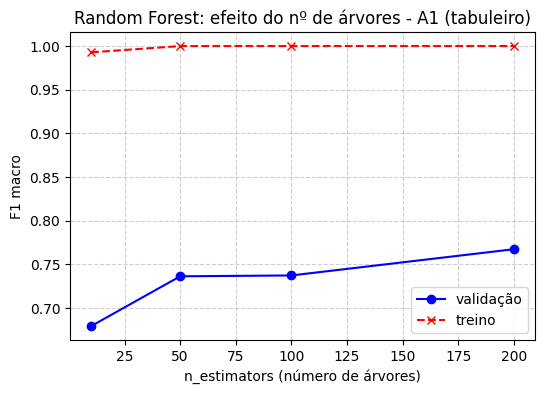

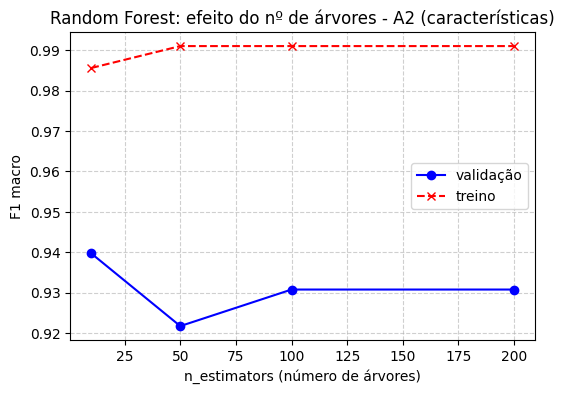

In [15]:
for ab in abordagens:
    s = resultados[resultados.abordagem == abordagens[ab]].groupby("n_arvores")[["f1_treino", "val_f1_macro"]].max()
    plt.figure(figsize=(6, 4))
    plt.plot(s.index, s["val_f1_macro"], label="validação", color="blue", marker="o", linestyle="-")
    plt.plot(s.index, s["f1_treino"], label="treino", color="red", marker="x", linestyle="--")
    plt.xlabel("n_estimators (número de árvores)")
    plt.ylabel("F1 macro")
    plt.title(f"Random Forest: efeito do nº de árvores - {abordagens[ab]}")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

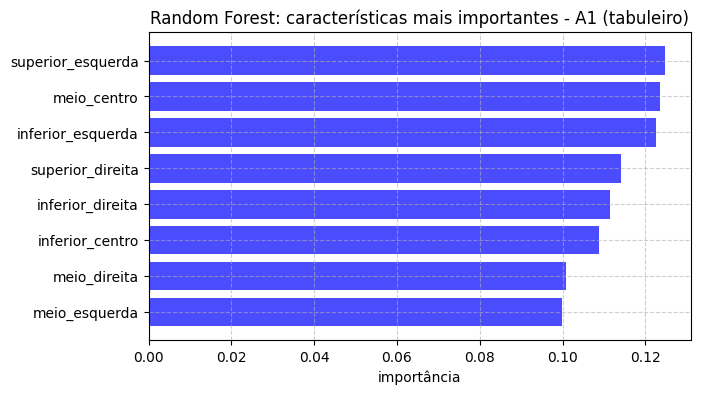

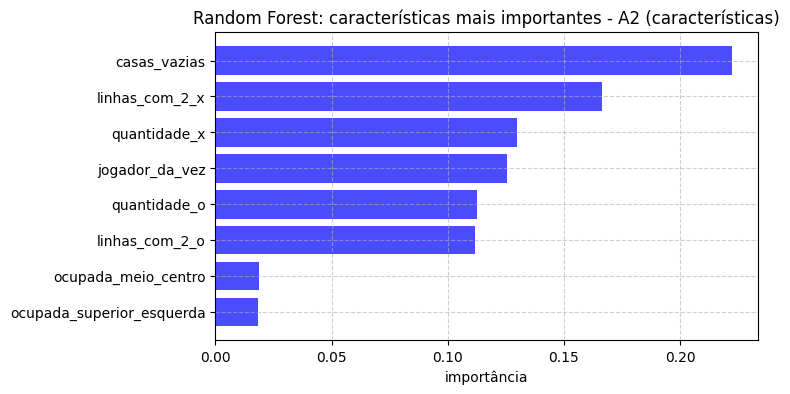

In [16]:
# importância das características (as 8 mais importantes de cada abordagem)
for ab in abordagens:
    modelo = melhor[ab]["modelo"]
    imp = pd.Series(modelo.feature_importances_, index=dados[ab]["X_train"].columns).sort_values(ascending=False).head(8)
    plt.figure(figsize=(7, 4))
    plt.barh(imp.index[::-1], imp.values[::-1], color="blue", alpha=0.7)
    plt.xlabel("importância")
    plt.title(f"Random Forest: características mais importantes - {abordagens[ab]}")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

**Comparação das abordagens (A1 × A2)**

Qual abordagem é mais adequada e menos custosa para este algoritmo?

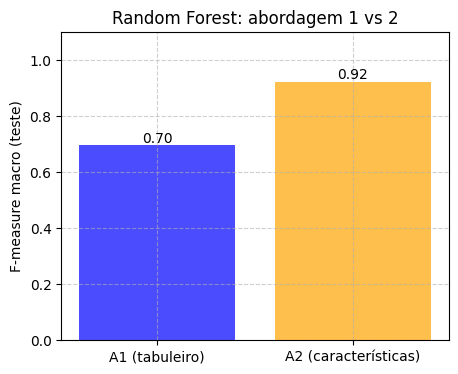

In [17]:
plt.figure(figsize=(5, 4))
plt.bar(tabela["abordagem"], tabela["f1_macro"], color=["blue", "orange"], alpha=0.7)
for i, v in enumerate(tabela["f1_macro"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.ylim(0, 1.1)
plt.ylabel("F-measure macro (teste)")
plt.title("Random Forest: abordagem 1 vs 2")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [18]:
tabela[["abordagem", "acuracia", "f1_macro", "gap_treino_val", "tempo_treino_ms", "tempo_pred_ms"]].round(3)

,abordagem,acuracia,f1_macro,gap_treino_val,tempo_treino_ms,tempo_pred_ms
0,A1 (tabuleiro),0.742,0.696,0.226,234.128,15.659
1,A2 (características),0.903,0.924,0.046,13.270,1.536


**Para o relatório**

- Explicar a diferença para a Árvore de Decisão: a floresta é um conjunto de árvores (bootstrap + subconjunto de características + voto).
- Justificar cada parâmetro testado e a escolha final.
- Comparar A1 e A2 em desempenho (F1 macro no teste) **e** em custo (tempos).
- Comparar com a árvore sozinha e comentar o overfitting (gráfico do nº de árvores e coluna `gap_treino_val`).
- Ressalvar que a classe Empate tem poucos exemplos em validação e teste.